# **De datos a decisiones:** Análisis de comportamiento de pago para reducir pérdidas por default

Este proyecto analiza el historial de comportamiento de pago de 30 mil clientes de una institución financiera, explorando 6 meses de datos que incluyen retrasos, abonos y saldos facturados. El análisis se desarrolla bajo dos enfoques complementarios:

**Modelado predictivo:** anticipar el incumplimiento de pago futuro a partir del comportamiento histórico del cliente.

**Análisis exploratorio:** identificar tendencias y señales tempranas de deterioro en la cartera, generando oportunidades para acciones preventivas y de negocio.

In [1]:
#

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import sys

BASE_DIR = Path().resolve().parent
sys.path.append(str(BASE_DIR / 'scripts'))

df = pd.read_csv(BASE_DIR / 'data' / 'datos_procesados.csv')

---

## Evolución de morosidad

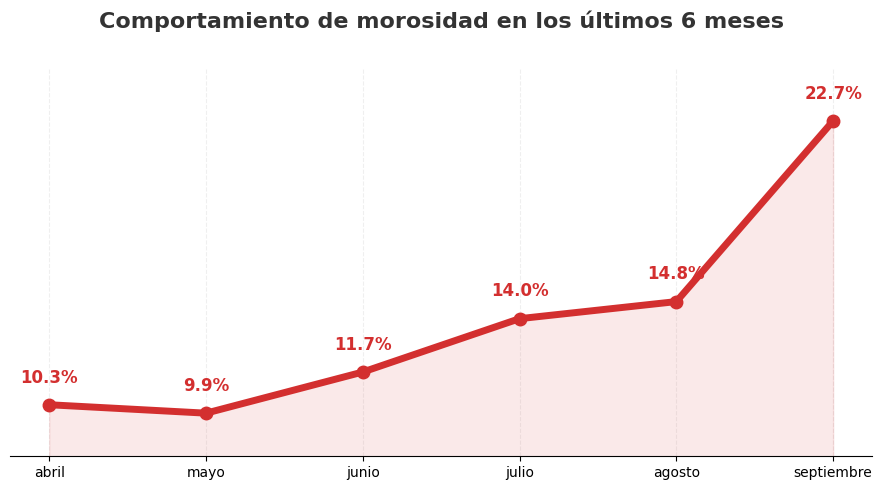

In [2]:
#-

resumen = (df.filter(like="comportamiento_") > 0).mean() * 100

tendencias = resumen.reset_index()
tendencias.columns = ["mes", "morosos"]

tendencias["mes"] = tendencias["mes"].str.replace("comportamiento_", "")
orden = ["abril", "mayo", "junio", "julio", "agosto", "septiembre"]
tendencias["mes"] = pd.Categorical(tendencias["mes"], categories=orden, ordered=True)

tendencias = tendencias.sort_values("mes")

#--------------------------------------------

plt.figure(figsize=(9, 5), facecolor='white')
ax = plt.gca()

low_limit = 8 

plt.plot(tendencias["mes"], tendencias["morosos"], 
         color="#d32f2f", marker='o', linewidth=5, markersize=9, zorder=3)

plt.fill_between(tendencias["mes"], tendencias["morosos"], low_limit, 
                 color="#d32f2f", alpha=0.1, zorder=2)

for x, y in zip(tendencias["mes"], tendencias["morosos"]):
    plt.text(x, y + 0.8, f"{y:.1f}%", ha='center', va='bottom', 
             fontsize=12, fontweight='bold', color="#d32f2f")

plt.title("Comportamiento de morosidad en los últimos 6 meses", 
          fontsize=16, fontweight='bold', pad=30, color="#333333")

plt.ylim(low_limit, 25) 

plt.xlabel("")
plt.ylabel("")
for spine in ["top", "right", "left"]: 
    ax.spines[spine].set_visible(False)

plt.yticks([])
plt.grid(axis='x', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

En los últimos 6 meses, la tasa de morosidad ha mostrado una tendencia creciente con señales de alerta. Tras un leve descenso en mayo (9.9%), los índices comenzaron a escalar de forma progresiva hasta alcanzar 14.8% en agosto. Sin embargo, es en septiembre donde se registra el incremento más crítico, llegando al 22.7%, lo que representa más del doble del nivel observado al inicio del período. Este comportamiento sugiere un deterioro acelerado en la capacidad de pago que requiere atención inmediata.

---

## Distribución de la morosidad

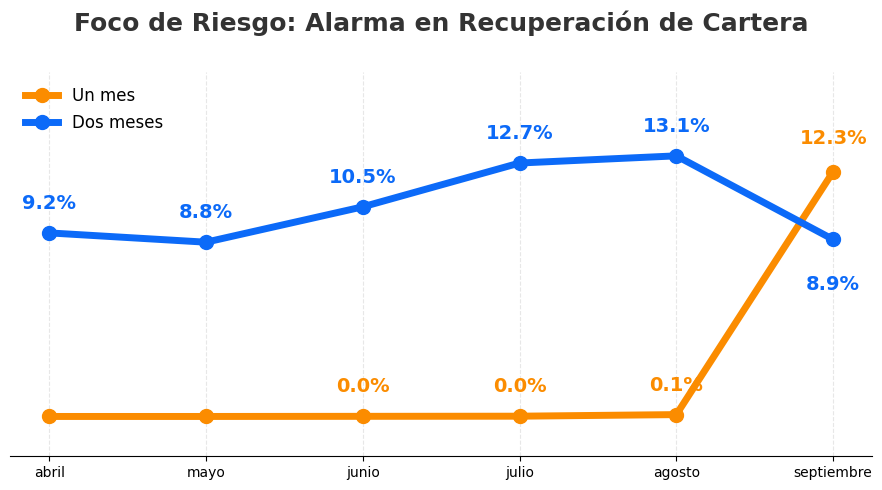

In [3]:
#-

cols_ordenadas = [f"comportamiento_{m}" for m in orden]

r1 = (df[cols_ordenadas] == 1).mean() * 100
r2 = (df[cols_ordenadas] == 2).mean() * 100
r3 = (df[cols_ordenadas] == 3).mean() * 100

mapear = lambda x: x.rename(lambda c: c.replace("comportamiento_", ""))

tendencias["retraso_1mes"] = tendencias["mes"].map(mapear(r1))
tendencias["retraso_2meses"] = tendencias["mes"].map(mapear(r2))
tendencias["retraso_3meses"] = tendencias["mes"].map(mapear(r3))

#--------------- GRAFICO

plt.figure(figsize=(9, 5), facecolor='white')
ax = plt.gca()

# Nueva paleta de colores: Naranja (1 mes) y Rojo (2 meses)
niveles = ["retraso_1mes", "retraso_2meses"]
colores = ["#fb8c00", "#0c6af8"] # Naranja y Rojo
labels = ["Un mes", "Dos meses"]

upper_limit = tendencias[niveles].max().max() + 5

for col, color, label in zip(niveles, colores, labels):
    plt.plot(tendencias["mes"], tendencias[col], 
             color=color, marker='o', linewidth=5, markersize=10, label=label, zorder=5)
    
    for x, y in zip(tendencias["mes"], tendencias[col]):
        # Solo graficamos si hay valor
        if y == 0: continue
        
        # Lógica de posición libre: en el cruce de septiembre, 
        # forzamos una separación para que no haya falla
        va = 'bottom'
        offset = 1.0
        
        if x == "septiembre":
            if col == "retraso_1mes": # Naranja (12.3%) sube
                va = 'bottom'
                offset = 1.2
            else: # Rojo (8.9%) baja
                va = 'top'
                offset = -1.8
        
        plt.text(x, y + offset, f"{y:.1f}%", ha='center', va=va, 
                 fontsize=14, fontweight='bold', color=color)

plt.title("Foco de Riesgo: Alarma en Recuperación de Cartera", 
          fontsize=18, fontweight='bold', pad=30, color="#333333")

plt.ylim(-2, upper_limit)
plt.legend(loc='upper left', frameon=False, fontsize=12)

# Limpieza total de ruido visual
plt.xlabel(""); plt.ylabel("")
for spine in ["top", "right", "left"]: 
    ax.spines[spine].set_visible(False)

plt.yticks([])
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

En el mes de agosto se alcanzó el mayor porcentaje (13.1%) de retraso para clientes con 60 días de mora; sin embargo, en septiembre disminuyó a 8.9%, regresando a niveles cercanos a los de inicio del período. Por otra parte, los clientes con un mes de retraso incrementaron significativamente, pasando de 0.1% en agosto a 12.3% en septiembre, lo que representa un deterioro repentino en la recuperación de cartera a corto plazo que requiere atención. Por otra parte, el porcentaje de clientes con retraso igual o mayor a 90 días se mantiene estable durante el periodo observando, entre 1% y 1.6% del total de clientes.

---

# Cierre de cartera del último mes


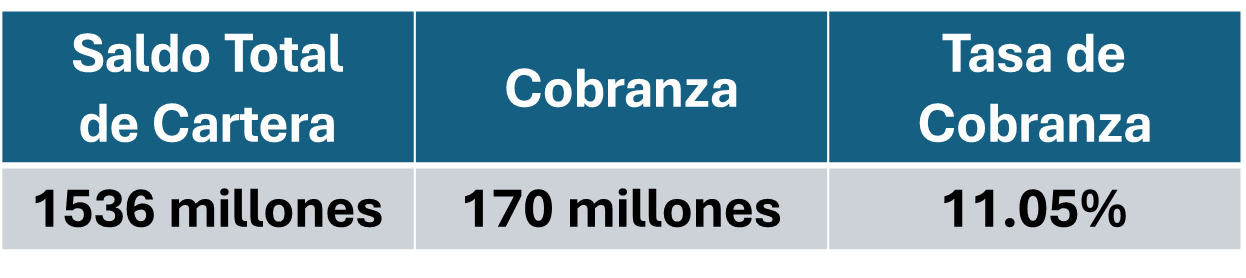

Para analizar cómo se distribuye la voluntad de pago, se realizó una clasificación de clientes basada en la proporción del saldo cubierto en el último mes:

$$ratio = \frac{\text{último\_abono}}{\text{último\_estado\_de\_cuenta}}$$

| # | Segmento | Condición | Descripción |
| --- | --- | --- | --- |
| 1 | **Inactivos** | Sin saldo pendiente | Sin saldo al corte. Cuentas liquidadas, canceladas o con saldo a favor. No generan intereses. |
| 2 | **Sin abono** | Abonó 0% | Tienen saldo pero no realizaron ningún pago. Mayor riesgo inmediato y primer paso hacia la mora. |
| 3 | **Pago mínimo** | Abonó < 10% | Pagan solo lo mínimo. Maximizan intereses para el emisor, pero son vulnerables financieramente. |
| 4 | **Parcial bajo** | Abonó 10% - 20% | Pagan más del mínimo pero menos de una quinta parte. Intención de pago con capacidad limitada. |
| 5 | **Parcial alto** | Abonó 20% - 99% | Porción significativa. Reducen deuda activamente. Perfil sólido. |
| 6 | **Totalero+** | Liquidó 100% | Liquidan todo su saldo cada mes. Menor riesgo crediticio y menor rentabilidad por intereses. |

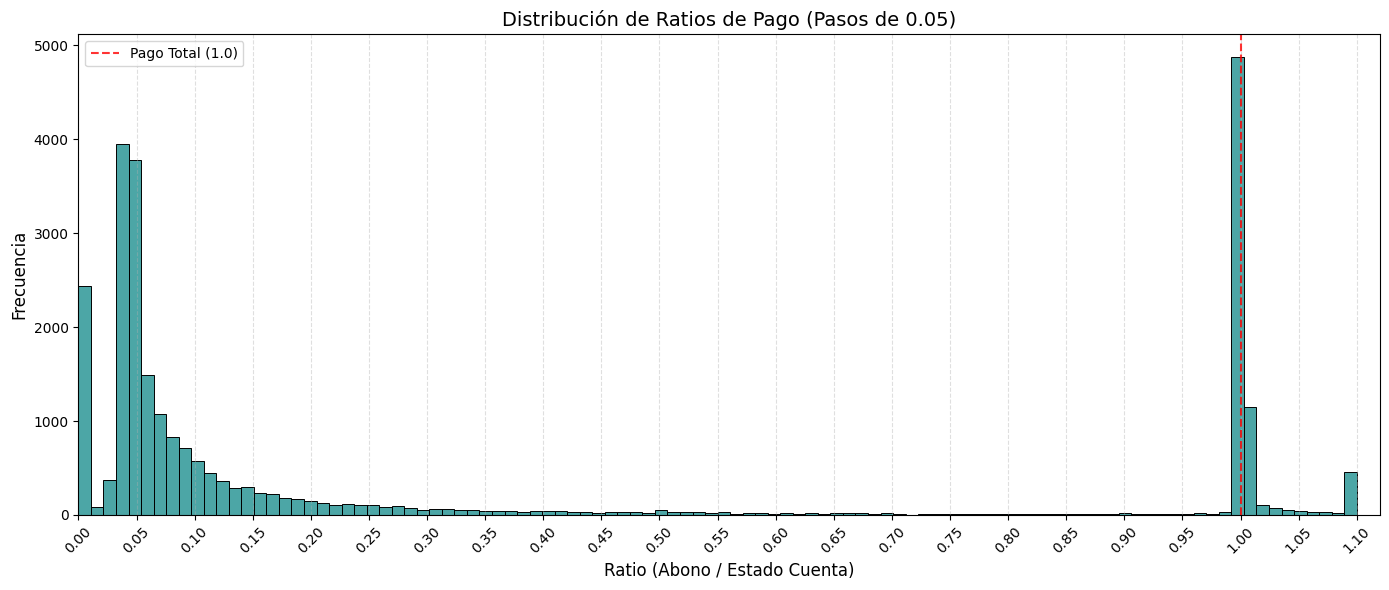

In [4]:
# -

# Gráfica para visualizar la distribución del cubrimiento de deuda

df_filtrado = df[df['estado_cuenta_agosto'] > 0].copy()
df_filtrado['ratio_pago'] = df_filtrado['abono_septiembre'] / df_filtrado['estado_cuenta_agosto']
df_filtrado['ratio_clipped'] = df_filtrado['ratio_pago'].clip(upper=1.1)

plt.figure(figsize=(14, 6))
sns.histplot(df_filtrado['ratio_clipped'], bins=102, kde=False, color='teal', edgecolor='black', alpha=0.7)

ticks = np.arange(0, 1.15, 0.05)
plt.xticks(ticks, rotation=45)
plt.axvline(1.0, color='red', linestyle='--', alpha=0.8, label='Pago Total (1.0)')

plt.title('Distribución de Ratios de Pago (Pasos de 0.05)', fontsize=14)
plt.xlabel('Ratio (Abono / Estado Cuenta)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xlim(0, 1.12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

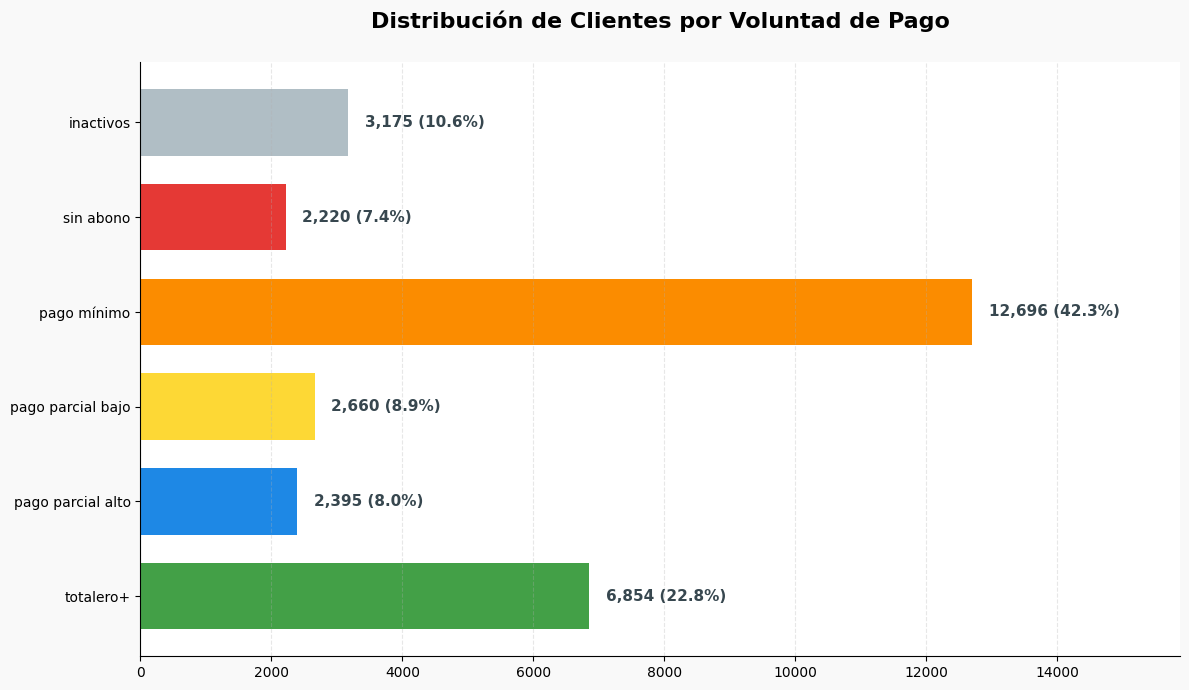

In [5]:
#--

# 1. Definición de Categorías (Tu lógica original)
condiciones = [
    (df['estado_cuenta_agosto'] <= 0),
    (df['estado_cuenta_agosto'] > 0) & (df['abono_septiembre'] / df['estado_cuenta_agosto'] <= 0),
    (df['estado_cuenta_agosto'] > 0) & (df['abono_septiembre'] / df['estado_cuenta_agosto'] <= 0.10),
    (df['estado_cuenta_agosto'] > 0) & (df['abono_septiembre'] / df['estado_cuenta_agosto'] <= 0.20),
    (df['estado_cuenta_agosto'] > 0) & (df['abono_septiembre'] / df['estado_cuenta_agosto'] < 0.99),
    (df['estado_cuenta_agosto'] > 0) & (df['abono_septiembre'] / df['estado_cuenta_agosto'] >= 0.99),
]

nombres = ['inactivos', 'sin abono', 'pago mínimo', 'pago parcial bajo', 'pago parcial alto', 'totalero+']

# 2. Procesamiento de datos
df['categoria'] = np.select(condiciones, nombres, default='Otros')
bucket = df['categoria'].value_counts().reindex(nombres).fillna(0).reset_index()
bucket.columns = ['categoria', 'cantidad']

# --- AQUÍ ESTABA EL TRUCO ---
total_clientes = bucket['cantidad'].sum() 
# Invertimos para que 'Totalero+' salga hasta arriba en el gráfico de barras
bucket_plot = bucket.iloc[::-1].copy()
colores_alt = ['#43A047', '#1E88E5', '#FDD835', '#FB8C00', '#E53935', '#B0BEC5']

# 3. Gráfica
plt.figure(figsize=(12, 7), facecolor='#F9F9F9')
bars = plt.barh(bucket_plot['categoria'], bucket_plot['cantidad'], color=colores_alt, height=0.7)

# 4. Etiquetas de datos (Corregidas y robustas)
for bar in bars:
    width = bar.get_width()
    # Calculamos el porcentaje basado en el total
    pct = (width / total_clientes) * 100 if total_clientes > 0 else 0
    
    plt.text(
        width + (bucket['cantidad'].max() * 0.02), # Espaciado dinámico basado en el valor máximo
        bar.get_y() + bar.get_height()/2, 
        f'{int(width):,} ({pct:.1f}%)', 
        va='center', 
        ha='left', # Alineación horizontal a la izquierda del punto de inserción
        fontsize=11, 
        fontweight='bold', 
        color='#37474F'
    )

# 5. Detalles finales
plt.title('Distribución de Clientes por Voluntad de Pago', fontsize=16, fontweight='bold', pad=25)
plt.xlim(0, bucket['cantidad'].max() * 1.25) # Damos 25% de aire para las etiquetas
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

El gráfico muestra que:

1. **La mayoría paga solo el mínimo** — con 42.3%, es el comportamiento dominante y el más riesgoso para la rentabilidad del portafolio, ya que genera más intereses pero también mayor riesgo de caer en morosidad.

2. **Los "totaleros+" son el segundo grupo más grande** (22.8%) — clientes que liquidan su saldo, los más sanos financieramente pero los menos rentables en intereses.

3. **Sin abono — 2,220 clientes (7.4%):** Tienen deuda activa pero **no han realizado ningún pago**, representando el riesgo más inmediato de cartera vencida.

4. **Inactivos — 3,175 clientes (10.6%):** No registran actividad reciente; pueden tener saldo pendiente pero sin movimiento ni pago, lo que sugiere abandono del producto o incapacidad de pago.


| Segmento | Clientes | % del total |
|---|---|---|
| Sin abono | 2,220 | 7.4% |
| Inactivos | 3,175 | 10.6% |
| **Total en riesgo crítico** | **5,395** | **~18%** |

Aproximadamente 1 de cada 5 clientes no está generando ningún flujo de recuperación, lo que representa una prioridad alta para estrategias de cobranza, reactivación o castigo de cartera.